<a href="https://colab.research.google.com/github/matthewecheverria2028-spec/latam-data-projects/blob/main/co2-emissions-project/latam_energy_co2_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Renewable Energy and CO2 Emissions in Latin America & the Caribbean

**Research question:** Does renewable energy adoption predict lower CO2 emissions per capita across Latin American and Caribbean (LAC) countries, controlling for economic growth (GDP per capita)?

**Why this question:** LAC has one of the world's cleanest electricity grids on average (hydropower especially), but emissions still vary a lot by country and are rising in some places as economies grow. Understanding that relationship while controlling for income matters for how the region plans its energy transition.

**Data source:** World Bank World Development Indicators (WDI), pulled via the `wbgapi` Python package.

**Structure of this notebook:**
1. Setup
2. Pull data (panel: country x year)
3. Clean and reshape
4. Exploratory plots
5. Regression (pooled OLS, then fixed effects)
6. Results and interpretation



## 1. Setup

`wbgapi` handles the World Bank API calls, and `linearmodels` provides panel regression with country and
year fixed effects.

In [1]:
!pip install wbgapi linearmodels --quiet

import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

pd.set_option('display.max_columns', None)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.9 MB/s eta 0:00:00


## 2. Pull data

**Indicators:**
- `EN.GHG.CO2.PC.CE.AR5` -- CO2 emissions excluding land use (t CO2e per capita), the outcome variable
- `EG.FEC.RNEW.ZS` -- renewable energy consumption (% of total final energy consumption), the variable of interest
- `NY.GDP.PCAP.KD` -- GDP per capita (constant 2015 US$), the control
- `EG.ELC.ACCS.ZS` -- access to electricity (% of population), pulled for context and not used in the models below

**Note:** The World Bank retired the older CO2 series (`EN.ATM.CO2E.PC`) from World Development Indicators, so this notebook uses the current CO2 series.

In [2]:
# Latin American & Caribbean countries, by ISO3 code
lac_countries = [
    'ARG', 'BHS', 'BRB', 'BLZ', 'BOL', 'BRA', 'CHL', 'COL', 'CRI',
    'DOM', 'ECU', 'SLV', 'GTM', 'GUY', 'HTI', 'HND', 'JAM', 'MEX',
    'NIC', 'PAN', 'PRY', 'PER', 'SUR', 'TTO', 'URY', 'VEN'
]

indicators = {
    'EN.GHG.CO2.PC.CE.AR5': 'co2_per_capita',
    'EG.FEC.RNEW.ZS': 'renewable_pct',
    'NY.GDP.PCAP.KD': 'gdp_per_capita',
    'EG.ELC.ACCS.ZS': 'electricity_access_pct',
}

years = range(2000, 2023)

# quick sanity check: confirm the indicator codes still exist / see alternatives
# wb.series.info(q='CO2')

df = wb.data.DataFrame(
    list(indicators.keys()),
    economy=lac_countries,
    time=years,
    labels=True,
    skipBlanks=True,
)

df.head()

,,Country,Series,YR2000,YR2001,YR2002,YR2003,YR2004,YR2005,YR2006,YR2007,YR2008,YR2009,YR2010,YR2011,YR2012,YR2013,YR2014,YR2015,YR2016,YR2017,YR2018,YR2019,YR2020,YR2021,YR2022
economy,series,,,,,,,,,,,,,,,,,,,,,,,,,
VEN,EN.GHG.CO2.PC.CE.AR5,"Venezuela, RB",Carbon dioxide (CO2) emissions excluding LULUC...,5.616135,5.735759,5.822355,5.522826,5.683342,5.821658,5.839704,5.641005,5.849621,5.810773,6.135924,5.926340,6.557327,6.451127,6.343687,5.754368,5.296083,4.971709,4.622691,4.159651,2.695313,2.686928,3.261048
URY,EN.GHG.CO2.PC.CE.AR5,Uruguay,Carbon dioxide (CO2) emissions excluding LULUC...,1.705526,1.532412,1.405485,1.400469,1.752891,1.694519,1.972485,1.856545,2.397328,2.366279,1.945983,2.340760,2.662798,2.289426,2.006177,2.047228,2.020902,1.890930,2.024136,2.106466,2.034000,2.517683,2.386673
TTO,EN.GHG.CO2.PC.CE.AR5,Trinidad and Tobago,Carbon dioxide (CO2) emissions excluding LULUC...,14.524381,16.393739,17.639944,20.275280,21.481217,27.052964,29.704132,30.251430,29.537432,28.573718,31.131793,31.066046,28.517129,27.847380,27.651536,27.235311,24.904886,23.989613,24.001595,24.357379,21.805191,20.974759,20.866009
SUR,EN.GHG.CO2.PC.CE.AR5,Suriname,Carbon dioxide (CO2) emissions excluding LULUC...,3.105469,3.125206,2.251934,2.438321,2.712274,3.251989,2.916969,2.664326,2.717754,2.671239,3.181718,3.517363,4.345461,4.021476,4.555653,4.687025,5.037286,4.127247,3.588246,4.393266,4.253352,4.400579,4.593975
PER,EN.GHG.CO2.PC.CE.AR5,Peru,Carbon dioxide (CO2) emissions excluding LULUC...,1.089786,0.999073,1.029822,0.999007,1.142474,1.133038,1.111759,1.204811,1.357796,1.452572,1.576300,1.678240,1.662298,1.687693,1.768256,1.802552,1.862891,1.762740,1.735141,1.792701,1.447468,1.798438,1.904083


## 3. Clean and reshape

`wbgapi` returns data in a wide, multi-index format that's a bit awkward. We'll reshape it into a clean **long panel**: one row per (country, year), one column per indicator.

In [3]:
# Reshape into long panel format
panel = wb.data.DataFrame(
    list(indicators.keys()),
    economy=lac_countries,
    time=years,
    skipBlanks=True,
).reset_index()

# wbgapi's long-format output columns are typically: economy, series, YR2000, YR2001, ...
# melt the year columns into rows
year_cols = [c for c in panel.columns if c.startswith('YR')]
panel_long = panel.melt(id_vars=['economy', 'series'], value_vars=year_cols,
                          var_name='year', value_name='value')
panel_long['year'] = panel_long['year'].str.replace('YR', '').astype(int)

# pivot so each indicator becomes its own column
panel_clean = panel_long.pivot_table(index=['economy', 'year'], columns='series', values='value').reset_index()
panel_clean = panel_clean.rename(columns=indicators)

print('Missing values per column:')
print(panel_clean.isna().sum())

# Drop rows missing our core variables (CO2, renewables, GDP)
panel_model = panel_clean.dropna(subset=['co2_per_capita', 'renewable_pct', 'gdp_per_capita']).copy()
panel_model['log_gdp_per_capita'] = np.log(panel_model['gdp_per_capita'])

panel_model.head()

Missing values per column:
series
economy                    0
year                       0
electricity_access_pct     0
renewable_pct             22
co2_per_capita             0
gdp_per_capita             0
dtype: int64


series,economy,year,electricity_access_pct,renewable_pct,co2_per_capita,gdp_per_capita,log_gdp_per_capita
0,ARG,2000,95.7,9.8,3.674858,10631.650364,9.271591
1,ARG,2001,95.5,11.5,3.490424,10051.944846,9.215521
2,ARG,2002,96.1,11.6,3.261037,8861.561993,9.089478
3,ARG,2003,96.3,10.8,3.518489,9545.531941,9.163828
4,ARG,2004,96.5,9.3,3.855797,10302.446532,9.240137


## 4. Exploratory plots

Always look at the data before modeling it.

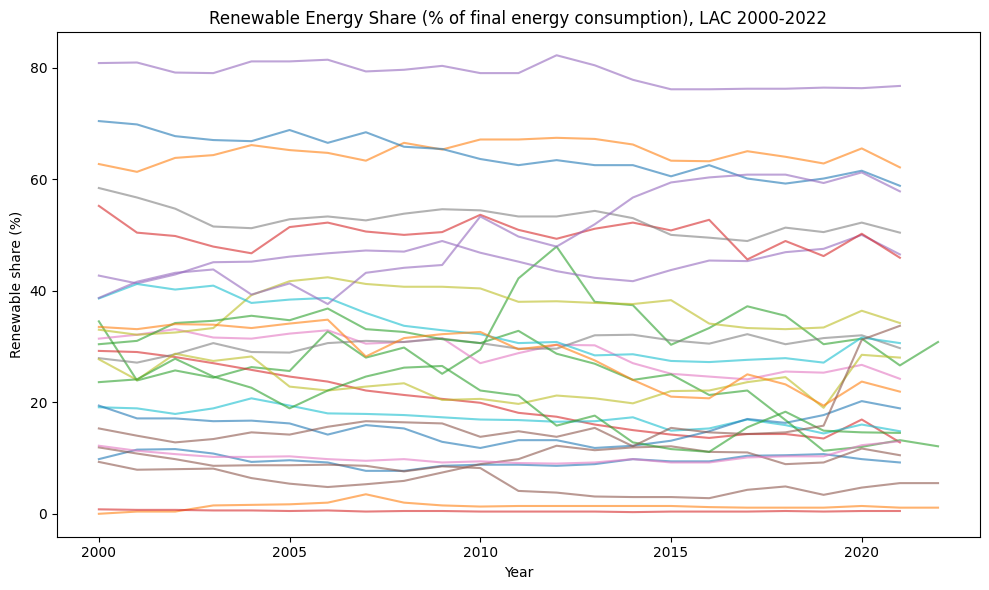

In [4]:
# Renewable share over time, one line per country
fig, ax = plt.subplots(figsize=(10, 6))
for country, grp in panel_model.groupby('economy'):
    ax.plot(grp['year'], grp['renewable_pct'], alpha=0.6, label=country)
ax.set_title('Renewable Energy Share (% of final energy consumption), LAC 2000-2022')
ax.set_xlabel('Year')
ax.set_ylabel('Renewable share (%)')
plt.tight_layout()
plt.show()

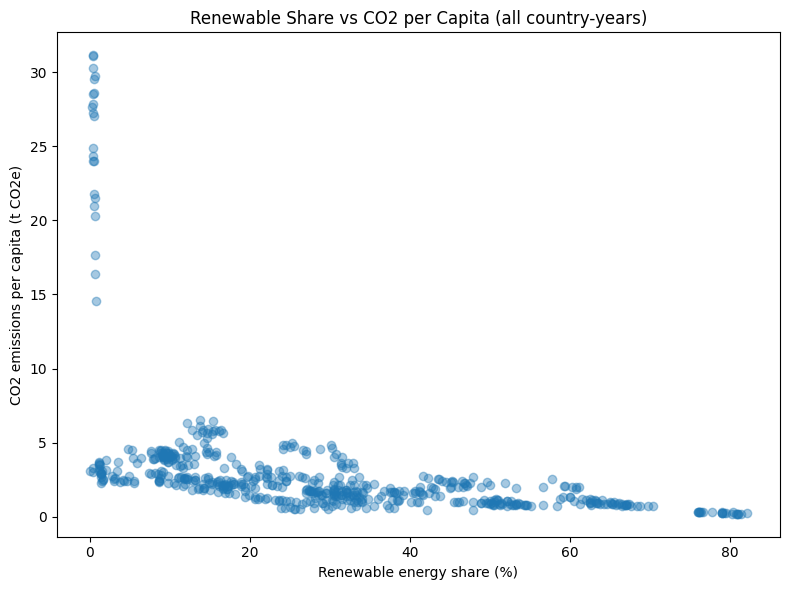

In [8]:
# Scatter: renewable share vs CO2 per capita
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(panel_model['renewable_pct'], panel_model['co2_per_capita'], alpha=0.4)
ax.set_xlabel('Renewable energy share (%)')
ax.set_ylabel('CO2 emissions per capita (t CO2e)')
ax.set_title('Renewable Share vs CO2 per Capita (all country-years)')
plt.tight_layout()
plt.show()

## 5. Regression

**Step 1: Pooled OLS** (simplest baseline, ignores country/year structure)

In [6]:
X = panel_model[['renewable_pct', 'log_gdp_per_capita']]
X = sm.add_constant(X)
y = panel_model['co2_per_capita']

pooled_model = sm.OLS(y, X).fit()
print(pooled_model.summary())

                            OLS Regression Results                            
Dep. Variable:         co2_per_capita   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.215
Method:                 Least Squares   F-statistic:                     79.88
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           2.51e-31
Time:                        09:09:00   Log-Likelihood:                -1630.8
No. Observations:                 576   AIC:                             3268.
Df Residuals:                     573   BIC:                             3281.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -3.4553      2

**Step 2: Fixed-effects panel regression**

This controls for each country's unique baseline level (e.g., Trinidad's oil economy vs. Costa Rica's) and for global year-to-year shocks (e.g., 2020 COVID dip). This is the more credible model -- it isolates the *within-country, over-time* relationship rather than just comparing countries to each other.

In [7]:
panel_indexed = panel_model.set_index(['economy', 'year'])

y_fe = panel_indexed['co2_per_capita']
X_fe = panel_indexed[['renewable_pct', 'log_gdp_per_capita']]

fe_model = PanelOLS(y_fe, X_fe, entity_effects=True, time_effects=True).fit()
print(fe_model)

                          PanelOLS Estimation Summary                           
Dep. Variable:         co2_per_capita   R-squared:                        0.1561
Estimator:                   PanelOLS   R-squared (Between):             -10.957
No. Observations:                 576   R-squared (Within):               0.1969
Date:                Thu, Oct 08 2026   R-squared (Overall):             -10.677
Time:                        09:09:00   Log-likelihood                   -749.88
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      48.637
Entities:                          26   P-value                           0.0000
Avg Obs:                       22.154   Distribution:                   F(2,526)
Min Obs:                       22.000                                           
Max Obs:                       23.000   F-statistic (robust):             48.637
                            

In [9]:
comparison = pd.DataFrame({
    'coefficient': [pooled_model.params['renewable_pct'], fe_model.params['renewable_pct']],
    'p_value': [pooled_model.pvalues['renewable_pct'], fe_model.pvalues['renewable_pct']],
}, index=['Pooled OLS', 'Two-way fixed effects'])

shrink = 1 - comparison.loc['Two-way fixed effects', 'coefficient'] / comparison.loc['Pooled OLS', 'coefficient']

print(comparison.round(3))
print(f'\nThe coefficient shrinks by {shrink:.0%} once country and year fixed effects are added.')

                       coefficient  p_value
Pooled OLS                  -0.078    0.000
Two-way fixed effects       -0.019    0.092

The coefficient shrinks by 76% once country and year fixed effects are added.


## 6. Results and interpretation

**Result.** In the pooled model, a higher renewable share is strongly associated with lower CO2 emissions per capita. Once country and year fixed effects are added, the coefficient falls from -0.078 (p < 0.001) to -0.019 (p = 0.09), a drop of about 75%, and is no longer significant at the 5% level. GDP per capita stays strongly significant in both models.

**Interpretation.** The pooled result is driven mostly by which countries have high renewable shares, not by emissions falling as a given country's renewable share rises. Fossil-fuel-dependent economies with very low renewable shares and very high per-capita emissions do much of the work in the cross-country comparison. Fixed effects remove those fixed country differences, and the within-country relationship that remains is much weaker.

**Caveats.** This is observational, not causal. Countries that expand renewables may differ in ways not measured here, such as hydropower geography, political stability, or industrial structure. A stronger design would use an instrument or a policy-based natural experiment.

**Policy takeaway.** Countries with higher renewable shares tend to have lower emissions, but this mostly reflects structural differences between economies. Policymakers should be cautious about assuming that raising one country's renewable share will, on its own and in the near term, lower that country's emissions. The full brief is in `policy_brief.md`.